<a href="https://colab.research.google.com/github/Seoyoung-Kim-Meister/analysis_Galaxus/blob/main/EY_Hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [113]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


from google.colab import drive
drive.mount('/content/EY.xlsx')



Drive already mounted at /content/EY.xlsx; to attempt to forcibly remount, call drive.mount("/content/EY.xlsx", force_remount=True).


In [114]:
import pandas as pd

df = pd.read_excel('/content/EY.xlsx/MyDrive/EY.xlsx')
display(df.head())

,id,first_name,last_name,birthdate,gender,zipcode,city,canton,income_monthly_chf,number_of_children,number_of_adults,has_job,available_for_job,job_looking_start,job_looking_end,Unnamed: 15
0,1,Dominic,Dubs,01.01.1764,2.0,1400,Yverdon-Les-Bains,Switzerland,13355.0,1.0,2.0,0,0.0,2023-04-10,2025-07-14,NaN
1,2,Ziegler,Jaspersen,01.01.1764,2.0,5210,Windisch,Aargau,4658.0,0.0,2.0,1,NaN,2023-04-14,2025-07-20,NaN
2,3,Hansrudolf,Schneebeli,01.01.1764,2.0,5512,Wohlenschwil,Aargau,7511.0,2.0,1.0,0,0.0,2023-04-11,2025-07-20,NaN
3,4,Linus,ROUMPIES,01.01.1764,1.0,1400,Yverdon-Les-Bains,Vaud,3896.0,3.0,2.0,1,NaN,2023-04-18,2025-07-22,NaN
4,5,Raphael,Schmid-Weibel,01.01.1764,2.0,8422,Pfungen,Switzerland,17346.0,1.0,1.0,0,1.0,2023-04-18,2025-07-22,Dummy Data Set:\nTest purpose only


In [115]:
df['birthdate'] = pd.to_datetime(df['birthdate'], format='%d.%m.%Y', errors='coerce')
df['birthdate'] = df['birthdate'].dt.year.astype('Int64')
display(df.head())

,id,first_name,last_name,birthdate,gender,zipcode,city,canton,income_monthly_chf,number_of_children,number_of_adults,has_job,available_for_job,job_looking_start,job_looking_end,Unnamed: 15
0,1,Dominic,Dubs,1764,2.0,1400,Yverdon-Les-Bains,Switzerland,13355.0,1.0,2.0,0,0.0,2023-04-10,2025-07-14,NaN
1,2,Ziegler,Jaspersen,1764,2.0,5210,Windisch,Aargau,4658.0,0.0,2.0,1,NaN,2023-04-14,2025-07-20,NaN
2,3,Hansrudolf,Schneebeli,1764,2.0,5512,Wohlenschwil,Aargau,7511.0,2.0,1.0,0,0.0,2023-04-11,2025-07-20,NaN
3,4,Linus,ROUMPIES,1764,1.0,1400,Yverdon-Les-Bains,Vaud,3896.0,3.0,2.0,1,NaN,2023-04-18,2025-07-22,NaN
4,5,Raphael,Schmid-Weibel,1764,2.0,8422,Pfungen,Switzerland,17346.0,1.0,1.0,0,1.0,2023-04-18,2025-07-22,Dummy Data Set:\nTest purpose only


In [116]:
df

,id,first_name,last_name,birthdate,gender,zipcode,city,canton,income_monthly_chf,number_of_children,number_of_adults,has_job,available_for_job,job_looking_start,job_looking_end,Unnamed: 15
0,1,Dominic,Dubs,1764,2.0,1400,Yverdon-Les-Bains,Switzerland,13355.0,1.0,2.0,0,0.0,2023-04-10,2025-07-14,NaN
1,2,Ziegler,Jaspersen,1764,2.0,5210,Windisch,Aargau,4658.0,0.0,2.0,1,NaN,2023-04-14,2025-07-20,NaN
2,3,Hansrudolf,Schneebeli,1764,2.0,5512,Wohlenschwil,Aargau,7511.0,2.0,1.0,0,0.0,2023-04-11,2025-07-20,NaN
3,4,Linus,ROUMPIES,1764,1.0,1400,Yverdon-Les-Bains,Vaud,3896.0,3.0,2.0,1,NaN,2023-04-18,2025-07-22,NaN
4,5,Raphael,Schmid-Weibel,1764,2.0,8422,Pfungen,Switzerland,17346.0,1.0,1.0,0,1.0,2023-04-18,2025-07-22,Dummy Data Set:\nTest purpose only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11207,11208,Aissa,Stress,1993,2.0,8400,Winterthur,Zürich,13214.0,2.0,2.0,0,0.0,2023-04-30,2025-09-29,NaN
11208,11209,Ladan,Streuli,1993,2.0,8400,Winterthur,Zürich,17715.0,2.0,2.0,0,0.0,2023-04-23,2025-10-24,NaN
11209,11210,Andrea,Stroitz,1993,1.0,8636,Wald ZH,Zürich,1595.0,2.0,1.0,0,0.0,2023-05-03,10010-12-31,NaN
11210,11211,Nicole,Strunck,1996,1.0,1167,Lussy-sur-Morges,Vaud,15869.0,3.0,1.0,0,0.0,2023-05-08,10010-12-31,NaN


In [117]:
df.dropna(subset=['birthdate'], inplace=True)
display(df.head())

,id,first_name,last_name,birthdate,gender,zipcode,city,canton,income_monthly_chf,number_of_children,number_of_adults,has_job,available_for_job,job_looking_start,job_looking_end,Unnamed: 15
0,1,Dominic,Dubs,1764,2.0,1400,Yverdon-Les-Bains,Switzerland,13355.0,1.0,2.0,0,0.0,2023-04-10,2025-07-14,NaN
1,2,Ziegler,Jaspersen,1764,2.0,5210,Windisch,Aargau,4658.0,0.0,2.0,1,NaN,2023-04-14,2025-07-20,NaN
2,3,Hansrudolf,Schneebeli,1764,2.0,5512,Wohlenschwil,Aargau,7511.0,2.0,1.0,0,0.0,2023-04-11,2025-07-20,NaN
3,4,Linus,ROUMPIES,1764,1.0,1400,Yverdon-Les-Bains,Vaud,3896.0,3.0,2.0,1,NaN,2023-04-18,2025-07-22,NaN
4,5,Raphael,Schmid-Weibel,1764,2.0,8422,Pfungen,Switzerland,17346.0,1.0,1.0,0,1.0,2023-04-18,2025-07-22,Dummy Data Set:\nTest purpose only


In [118]:
df.shape

(11119, 16)

In [119]:
df = df[(df['birthdate'] >= 1951) & (df['birthdate'] <= 2010)]
display(df.head())

,id,first_name,last_name,birthdate,gender,zipcode,city,canton,income_monthly_chf,number_of_children,number_of_adults,has_job,available_for_job,job_looking_start,job_looking_end,Unnamed: 15
577,578,Walker,Jauregui Estrada,1951,1.0,1700,Fribourg,Fribourg / Freiburg,14361.0,2.0,1.0,0,0.0,2023-04-18,10010-12-31,NaN
578,579,Silvia,Liechti - Senior,1952,1.0,8266,Steckborn,Thurgau,7448.0,2.0,1.0,0,0.0,2023-05-02,10010-12-31,NaN
579,580,Marcel,Rebelo Rodrigues,1953,1.0,4125,Riehen,Basel-Stadt,16757.0,0.0,1.0,0,1.0,2023-04-30,2025-09-08,NaN
580,581,Slawomir Janusz,Gautschi,1953,1.0,4125,Riehen,Basel-Stadt,13580.0,2.0,2.0,0,0.0,2023-04-24,10010-12-31,NaN
581,582,Rolf,Ghouzlaoui,1953,1.0,8006,Zürich,Zürich,3467.0,1.0,2.0,0,0.0,2023-04-14,10010-12-31,NaN


In [120]:
cantons_to_drop = ['Hong Kong', 'Austria', 'Italy', 'Liechtenstein', 'Nigeria', 'Germany', 'France']
df = df[~df['canton'].isin(cantons_to_drop)]



In [121]:
df.shape

(9377, 16)

In [122]:
df_clean.shape
df_canton_switzerland.shape

(897, 16)

In [176]:
df_clean.shape

(8480, 16)

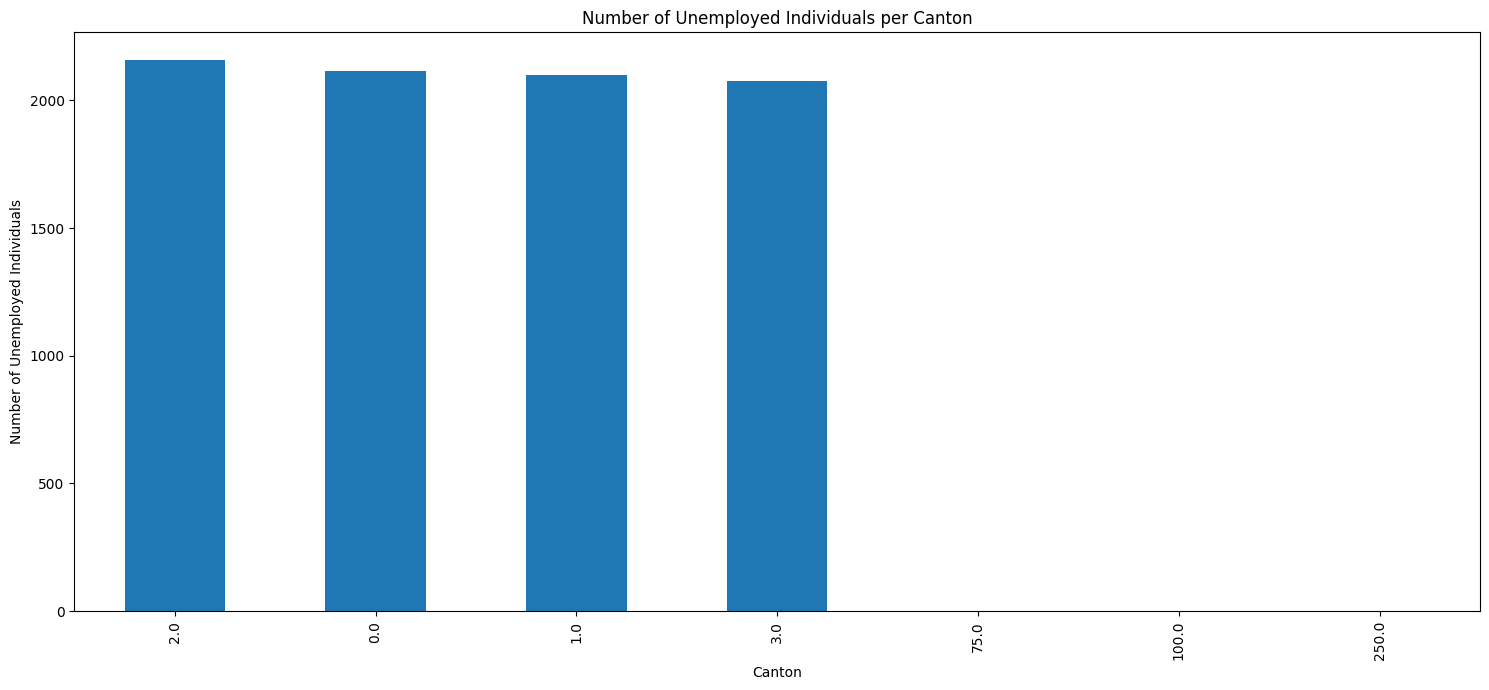

In [180]:
canton_counts_clean_children = df_clean['number_of_children'].value_counts()
plt.figure(figsize=(15, 7))
canton_counts_clean_children.plot(kind='bar')
plt.title('Number of Unemployed Individuals per Canton')
plt.xlabel('Canton')
plt.ylabel('Number of Unemployed Individuals')
plt.tight_layout()
plt.show()

In [181]:
print(canton_counts_clean_children)

number_of_children
2.0      2158
0.0      2114
1.0      2097
3.0      2076
75.0        1
100.0       1
250.0       1
Name: count, dtype: int64


In [123]:
df_no_job_clean = df_clean[(df_clean['has_job'] ==0)]
df_yes_job_clean = df_clean[(df_clean['has_job'] ==1)]
df_no_job_switzerland = df_canton_switzerland[(df_canton_switzerland['has_job'] ==0)]
df_yes_job_switzerland = df_canton_switzerland[(df_canton_switzerland['has_job'] ==1)]

In [179]:
df_yes_job_clean.shape

(1900, 16)

In [124]:
df_no_job_clean.shape

(6580, 16)

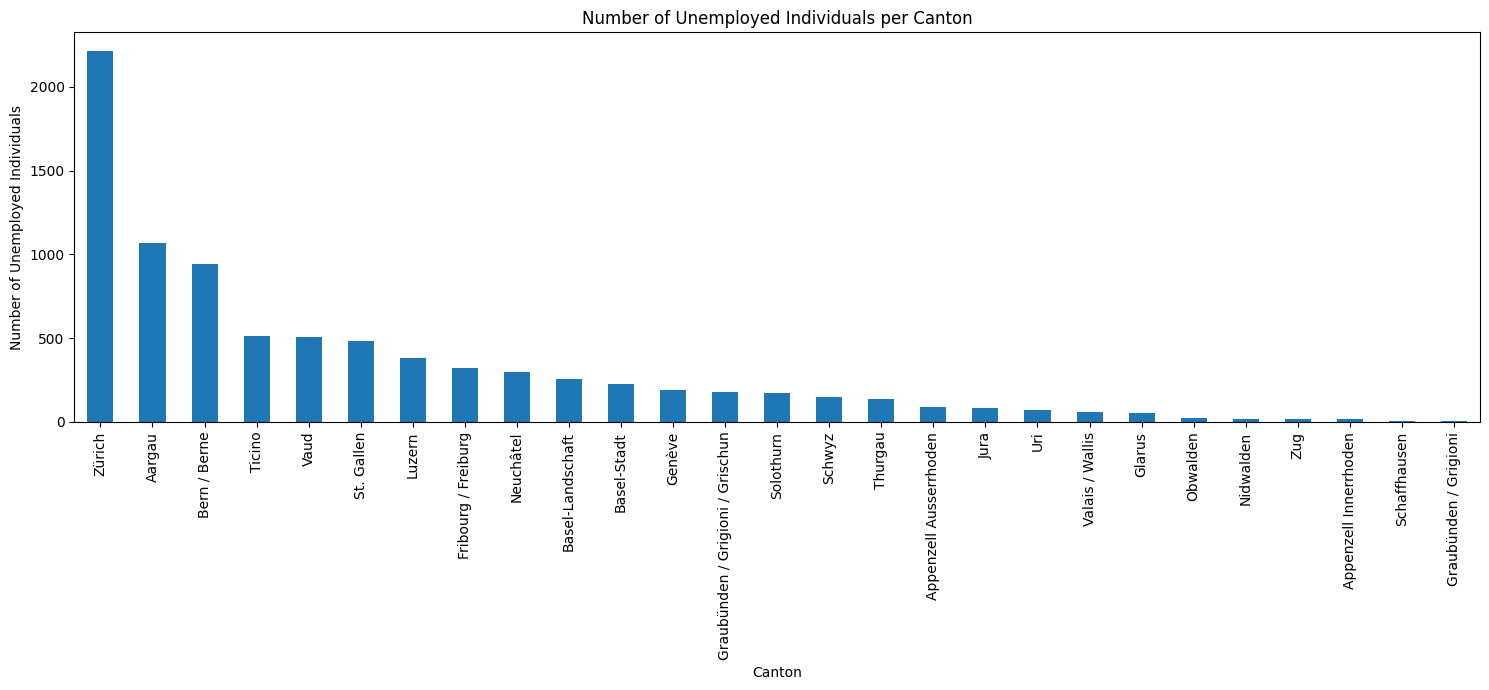

In [177]:
canton_counts_clean = df_clean['canton'].value_counts()
plt.figure(figsize=(15, 7))
canton_counts_clean.plot(kind='bar')
plt.title('Number of Unemployed Individuals per Canton')
plt.xlabel('Canton')
plt.ylabel('Number of Unemployed Individuals')
plt.tight_layout()
plt.show()


In [178]:
print(canton_counts_clean)

canton
Zürich                              2215
Aargau                              1066
Bern / Berne                         943
Ticino                               514
Vaud                                 509
St. Gallen                           482
Luzern                               379
Fribourg / Freiburg                  323
Neuchâtel                            300
Basel-Landschaft                     259
Basel-Stadt                          229
Genève                               189
Graubünden / Grigioni / Grischun     176
Solothurn                            171
Schwyz                               150
Thurgau                              138
Appenzell Ausserrhoden                87
Jura                                  84
Uri                                   70
Valais / Wallis                       60
Glarus                                56
Obwalden                              21
Nidwalden                             18
Zug                                   17
Appenzell

In [125]:
df_yes_job_clean.shape

(1900, 16)

In [126]:
df_no_job_switzerland.shape

(667, 16)

In [129]:
df_yes_job_switzerland.shape

(230, 16)

In [130]:
df_no_job_clean

,id,first_name,last_name,birthdate,gender,zipcode,city,canton,income_monthly_chf,number_of_children,number_of_adults,has_job,available_for_job,job_looking_start,job_looking_end,Unnamed: 15
577,578,Walker,Jauregui Estrada,1951,1.0,1700,Fribourg,Fribourg / Freiburg,14361.0,2.0,1.0,0,0.0,2023-04-18,10010-12-31,NaN
578,579,Silvia,Liechti - Senior,1952,1.0,8266,Steckborn,Thurgau,7448.0,2.0,1.0,0,0.0,2023-05-02,10010-12-31,NaN
579,580,Marcel,Rebelo Rodrigues,1953,1.0,4125,Riehen,Basel-Stadt,16757.0,0.0,1.0,0,1.0,2023-04-30,2025-09-08,NaN
580,581,Slawomir Janusz,Gautschi,1953,1.0,4125,Riehen,Basel-Stadt,13580.0,2.0,2.0,0,0.0,2023-04-24,10010-12-31,NaN
581,582,Rolf,Ghouzlaoui,1953,1.0,8006,Zürich,Zürich,3467.0,1.0,2.0,0,0.0,2023-04-14,10010-12-31,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11207,11208,Aissa,Stress,1993,2.0,8400,Winterthur,Zürich,13214.0,2.0,2.0,0,0.0,2023-04-30,2025-09-29,NaN
11208,11209,Ladan,Streuli,1993,2.0,8400,Winterthur,Zürich,17715.0,2.0,2.0,0,0.0,2023-04-23,2025-10-24,NaN
11209,11210,Andrea,Stroitz,1993,1.0,8636,Wald ZH,Zürich,1595.0,2.0,1.0,0,0.0,2023-05-03,10010-12-31,NaN
11210,11211,Nicole,Strunck,1996,1.0,1167,Lussy-sur-Morges,Vaud,15869.0,3.0,1.0,0,0.0,2023-05-08,10010-12-31,NaN


In [140]:
df_no_job_clean_wref = pd.read_excel('/content/EY.xlsx/MyDrive/df_no_job_clean_wref.xlsx')


In [167]:
df_no_job_clean_wref.shape

(2750, 16)

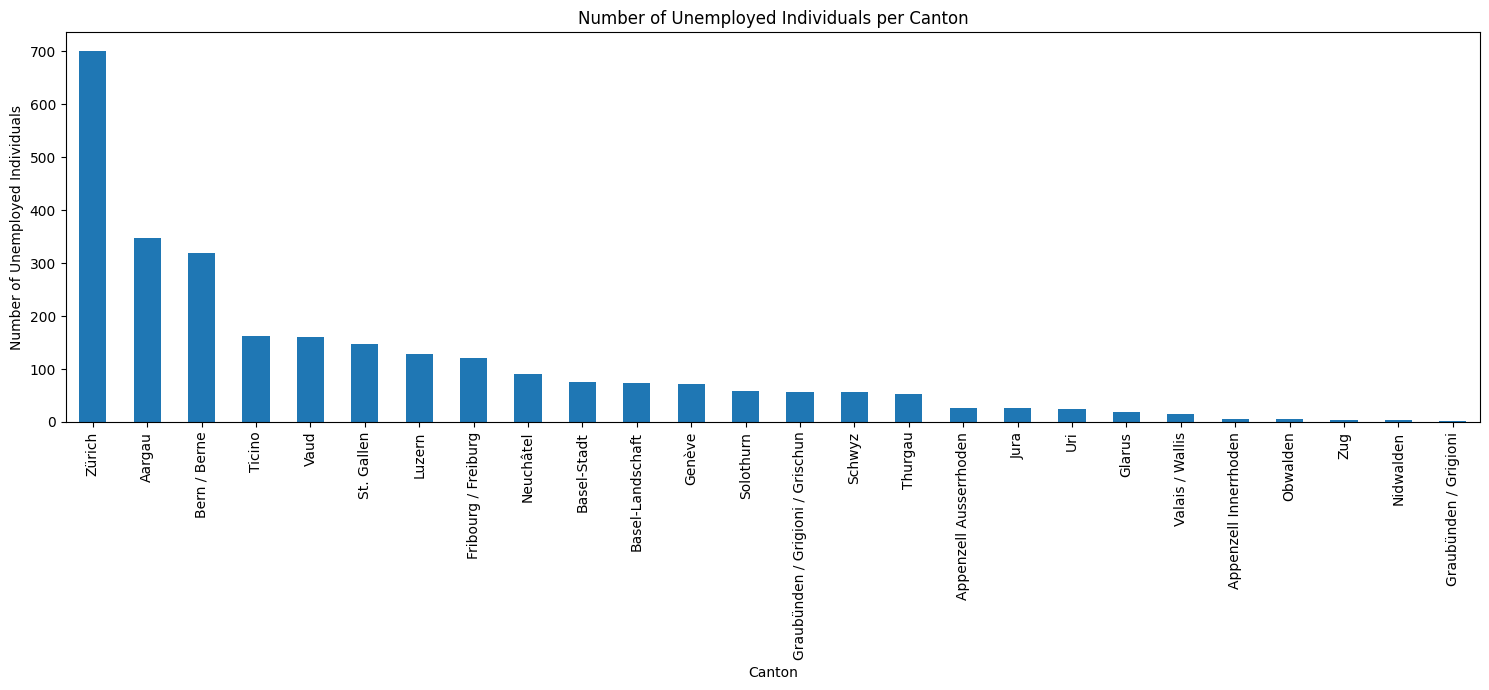

In [172]:
canton_counts_wref = df_no_job_clean_wref['canton'].value_counts()
plt.figure(figsize=(15, 7))
canton_counts_wref.plot(kind='bar')
plt.title('Number of Unemployed Individuals per Canton')
plt.xlabel('Canton')
plt.ylabel('Number of Unemployed Individuals')
plt.tight_layout()
plt.show()


In [169]:
print(canton_counts_wref)

canton
Zürich                              701
Aargau                              348
Bern / Berne                        319
Ticino                              162
Vaud                                160
St. Gallen                          148
Luzern                              129
Fribourg / Freiburg                 120
Neuchâtel                            91
Basel-Stadt                          75
Basel-Landschaft                     74
Genève                               71
Solothurn                            58
Graubünden / Grigioni / Grischun     56
Schwyz                               56
Thurgau                              52
Appenzell Ausserrhoden               27
Jura                                 26
Uri                                  24
Glarus                               19
Valais / Wallis                      15
Appenzell Innerrhoden                 5
Obwalden                              5
Zug                                   4
Nidwalden                        

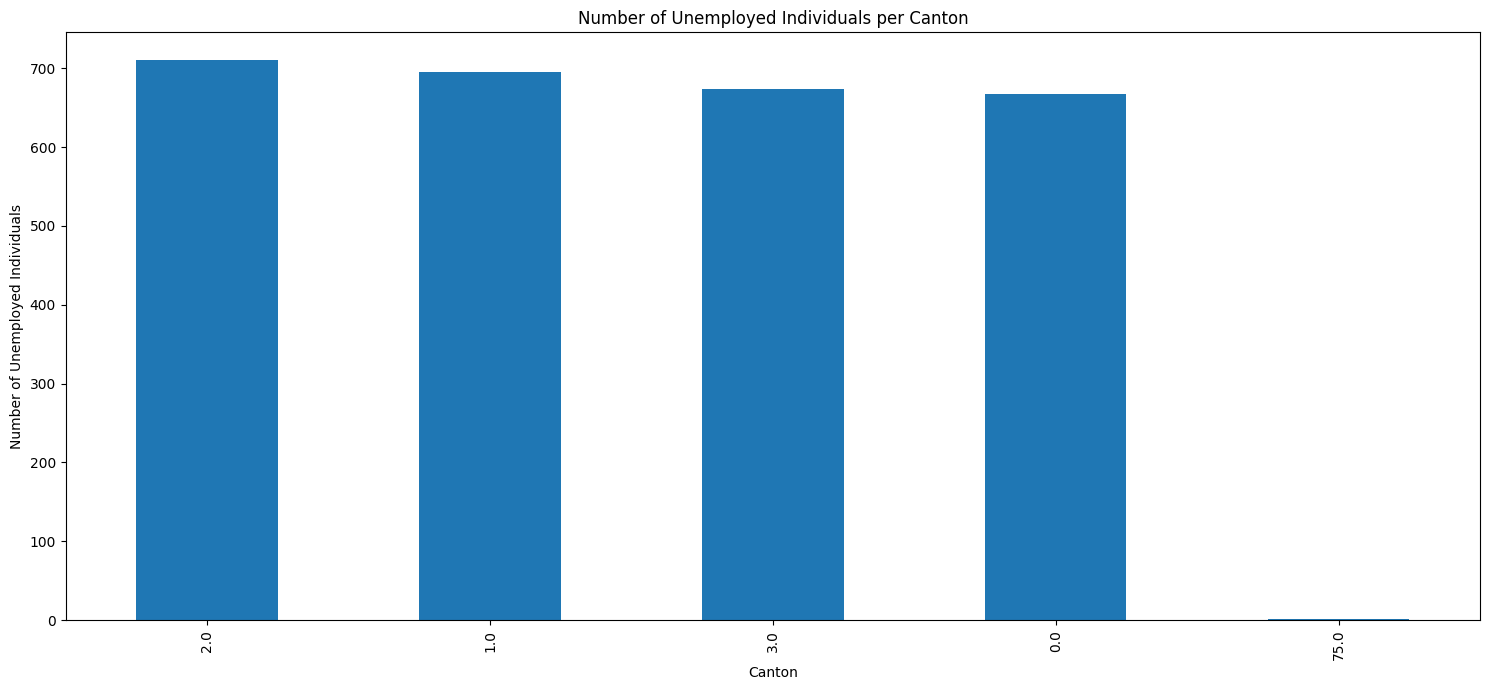

In [182]:
canton_counts_wref_children = df_no_job_clean_wref['number_of_children'].value_counts()
plt.figure(figsize=(15, 7))
canton_counts_wref_children.plot(kind='bar')
plt.title('Number of Unemployed Individuals per Canton')
plt.xlabel('Canton')
plt.ylabel('Number of Unemployed Individuals')
plt.tight_layout()
plt.show()

In [183]:
print(canton_counts_wref_children)

number_of_children
2.0     710
1.0     695
3.0     674
0.0     667
75.0      1
Name: count, dtype: int64


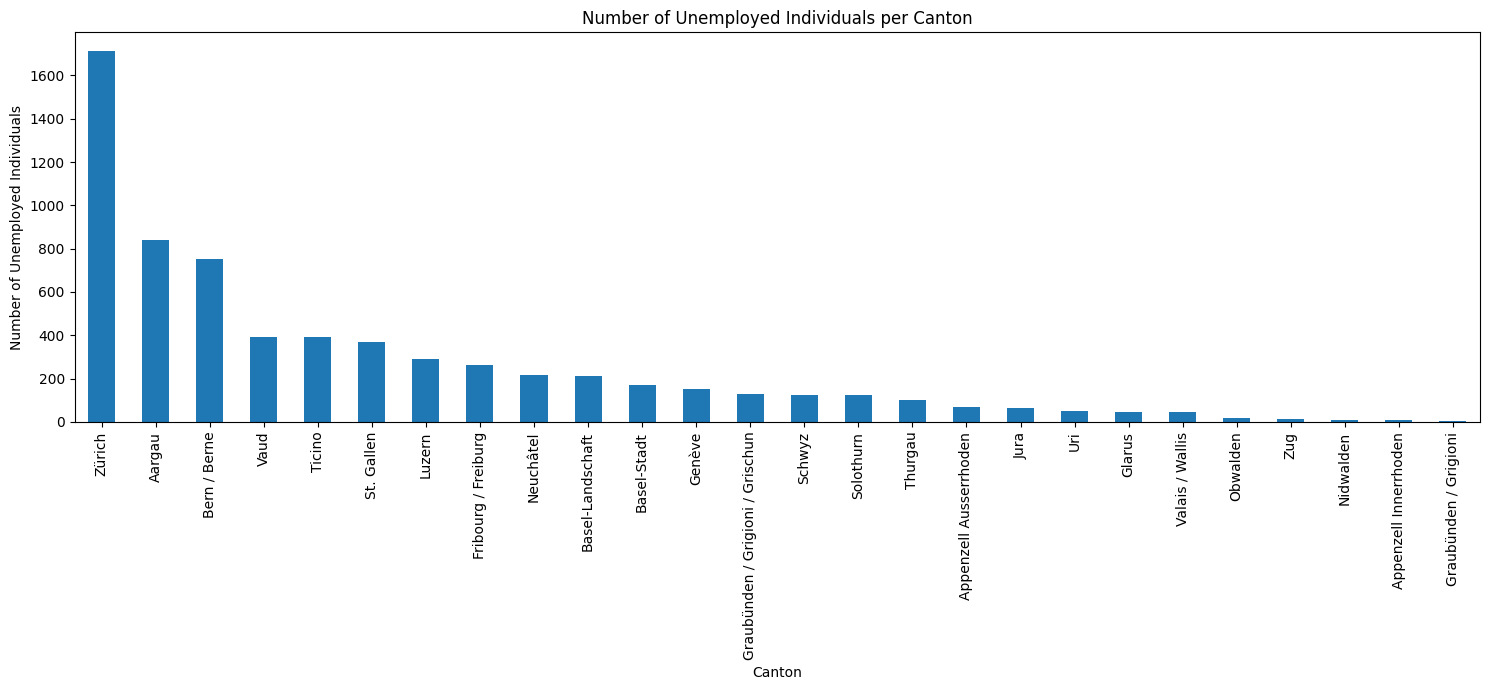

In [170]:
canton_counts = df_no_job_clean['canton'].value_counts()
plt.figure(figsize=(15, 7))
canton_counts.plot(kind='bar')
plt.title('Number of Unemployed Individuals per Canton')
plt.xlabel('Canton')
plt.ylabel('Number of Unemployed Individuals')
plt.tight_layout()
plt.show()

In [171]:
print(canton_counts)

canton
Zürich                              1713
Aargau                               840
Bern / Berne                         754
Vaud                                 392
Ticino                               390
St. Gallen                           367
Luzern                               292
Fribourg / Freiburg                  261
Neuchâtel                            218
Basel-Landschaft                     210
Basel-Stadt                          171
Genève                               152
Graubünden / Grigioni / Grischun     130
Schwyz                               126
Solothurn                            125
Thurgau                              100
Appenzell Ausserrhoden                71
Jura                                  64
Uri                                   51
Glarus                                48
Valais / Wallis                       45
Obwalden                              18
Zug                                   16
Nidwalden                             11
Appenzell

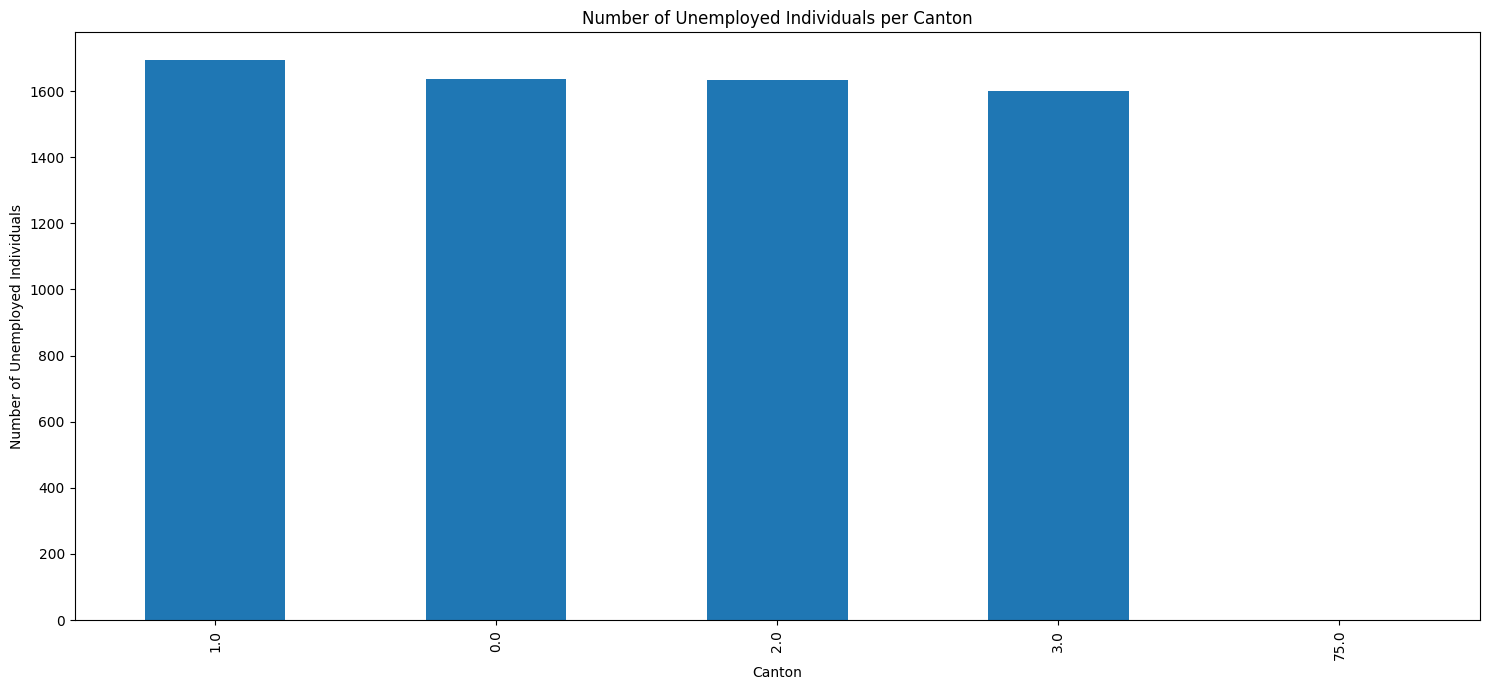

In [184]:
canton_counts_children = df_no_job_clean['number_of_children'].value_counts()
plt.figure(figsize=(15, 7))
canton_counts_children.plot(kind='bar')
plt.title('Number of Unemployed Individuals per Canton')
plt.xlabel('Canton')
plt.ylabel('Number of Unemployed Individuals')
plt.tight_layout()
plt.show()

In [185]:
print(canton_counts_children)

number_of_children
1.0     1693
0.0     1635
2.0     1632
3.0     1600
75.0       1
Name: count, dtype: int64


In [156]:
df_no_job_switzerland.shape

(667, 16)

In [158]:
print(canton_counts_switzerland)

canton
Switzerland    667
Name: count, dtype: int64


In [187]:
df_no_job_switzerland.to_excel('df_no_job_switzerland.xlsx', index=False)

In [188]:
df_clean.to_excel('df_clean.xlsx', index=False)

In [161]:
df_no_job_clean_wref_1 = df_no_job_clean_wref[(df_no_job_clean_wref['gender'] ==1)]
df_no_job_clean_wref_1.shape

(1727, 16)

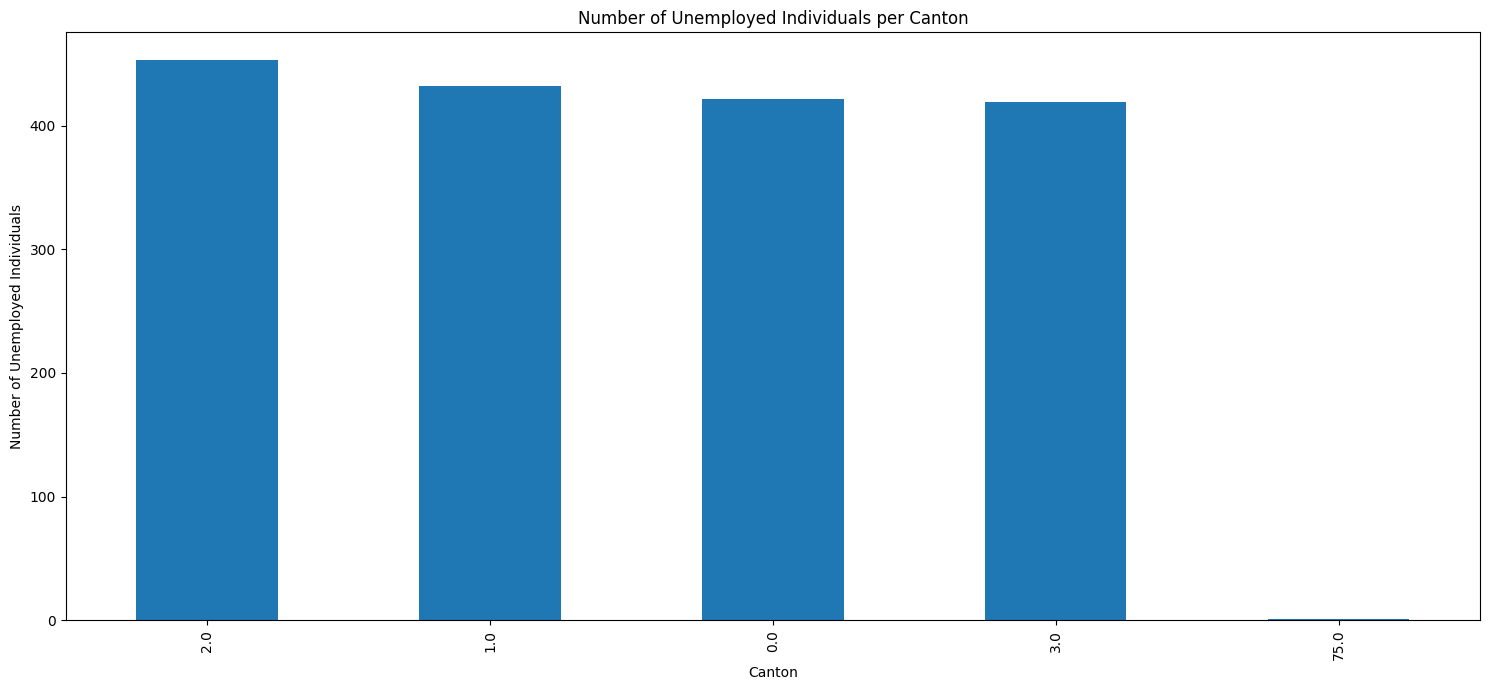

number_of_children
2.0     453
1.0     432
0.0     422
3.0     419
75.0      1
Name: count, dtype: int64


In [186]:
count_no_job_clean_wref_1 = df_no_job_clean_wref_1['number_of_children'].value_counts()
plt.figure(figsize=(15, 7))
count_no_job_clean_wref_1.plot(kind='bar')
plt.title('Number of Unemployed Individuals per Canton')
plt.xlabel('Canton')
plt.ylabel('Number of Unemployed Individuals')
plt.tight_layout()
plt.show()
print(count_no_job_clean_wref_1)

In [162]:
df_no_job_clean_wref_2 = df_no_job_clean_wref[(df_no_job_clean_wref['gender'] ==2)]
df_no_job_clean_wref_2.shape

(1012, 16)

In [163]:
df_no_job_clean_1 = df_no_job_clean[(df_no_job_clean['gender'] ==1)]
df_no_job_clean_1.shape

(2194, 16)

In [164]:
df_no_job_clean_2 = df_no_job_clean[(df_no_job_clean['gender'] ==2)]
df_no_job_clean_2.shape

(4344, 16)